**EDA — `data/raw/styles.csv`**

EDA dữ liệu sản phẩm gốc, phục vụ cho việc làm sạch và tạo thêm các thuộc tính mới.

Mục tiêu:
- Kiểm tra chất lượng dữ liệu trước khi làm sạch.
- Hiểu phân bố dữ liệu để có thể trích xuất hợp lý mà không phá vỡ phân bố.
- Phát hiện các vấn đề có thể ảnh hưởng đến mô hình.

In [ ]:
# Import thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent
sys.path.insert(0, str(ROOT_DIR))
from config.backend import RAW_DATA_PATH, CLEAN_DATA_PATH

RAW_DATA_PATH = ROOT_DIR / RAW_DATA_PATH
CLEAN_DATA_PATH = ROOT_DIR / CLEAN_DATA_PATH

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid")

df = pd.read_csv(RAW_DATA_PATH, on_bad_lines="skip")
df.shape

(44424, 10)

## **1. Tổng quan**

In [67]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 6.7 MB


In [69]:
missing = df.isna().sum()
missing[missing > 0]

baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

**Nhận xét:** `baseColour`, `season`, `year` và `productionDisplayName` có tỉ lệ missing rất thấp (< 0.04%), `usage` có tỉ lệ missing thấp (~0.7%) 

$\rightarrow$ Drop các dòng này.

In [70]:
df = df.dropna(
    subset=[
        "baseColour",
        "season",
        "year",
        "usage",
        "productDisplayName"
    ]
)

## **2. Kiểm tra dduplicate**

In [71]:
print("id duplicated:", df['id'].duplicated().sum())
print("Toàn bộ dòng duplicated:", df.duplicated().sum())
print("productDisplayName duplicated:", df['productDisplayName'].duplicated().sum())

key = ['productDisplayName', 'baseColour']
full_dup = df[df.duplicated(key, keep=False)].sort_values(key)
print(f"Số dòng trùng cả tên + màu (khác id): {len(full_dup)}  ({len(full_dup)/len(df):.1%} tổng data)")

id duplicated: 0
Toàn bộ dòng duplicated: 0
productDisplayName duplicated: 13271
Số dòng trùng cả tên + màu (khác id): 17572  (39.9% tổng data)


In [72]:
# Lấy hàng trùng cụ thể cả tên mô tả và màu
sample_name = full_dup['productDisplayName'].value_counts().index[0]
df[df['productDisplayName'] == sample_name]

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
1461,48728,Women,Accessories,Jewellery,Earrings,Silver,Summer,2015.0,Casual,Lucera Women Silver Earrings
1626,48717,Women,Accessories,Jewellery,Earrings,Silver,Summer,2012.0,Casual,Lucera Women Silver Earrings
2052,48710,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual,Lucera Women Silver Earrings
2356,48726,Women,Accessories,Jewellery,Earrings,Silver,Summer,2015.0,Casual,Lucera Women Silver Earrings
2682,48721,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual,Lucera Women Silver Earrings
...,...,...,...,...,...,...,...,...,...,...
39502,48593,Women,Accessories,Jewellery,Earrings,Silver,Summer,2012.0,Casual,Lucera Women Silver Earrings
41062,48701,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual,Lucera Women Silver Earrings
42698,48592,Women,Accessories,Jewellery,Earrings,Silver,Summer,2013.0,Casual,Lucera Women Silver Earrings
43164,48707,Women,Accessories,Jewellery,Earrings,Silver,Summer,2012.0,Casual,Lucera Women Silver Earrings


**Phát hiện:** Khoảng 40% dòng có cùng `productDisplayName` và `baseColour` nhưng khác id. Các dòng này không được xem là duplicate vì vẫn có thể khác season, year hoặc các thuộc tính khác.

## **3. Phân bố các biến phân loại (categorical)**

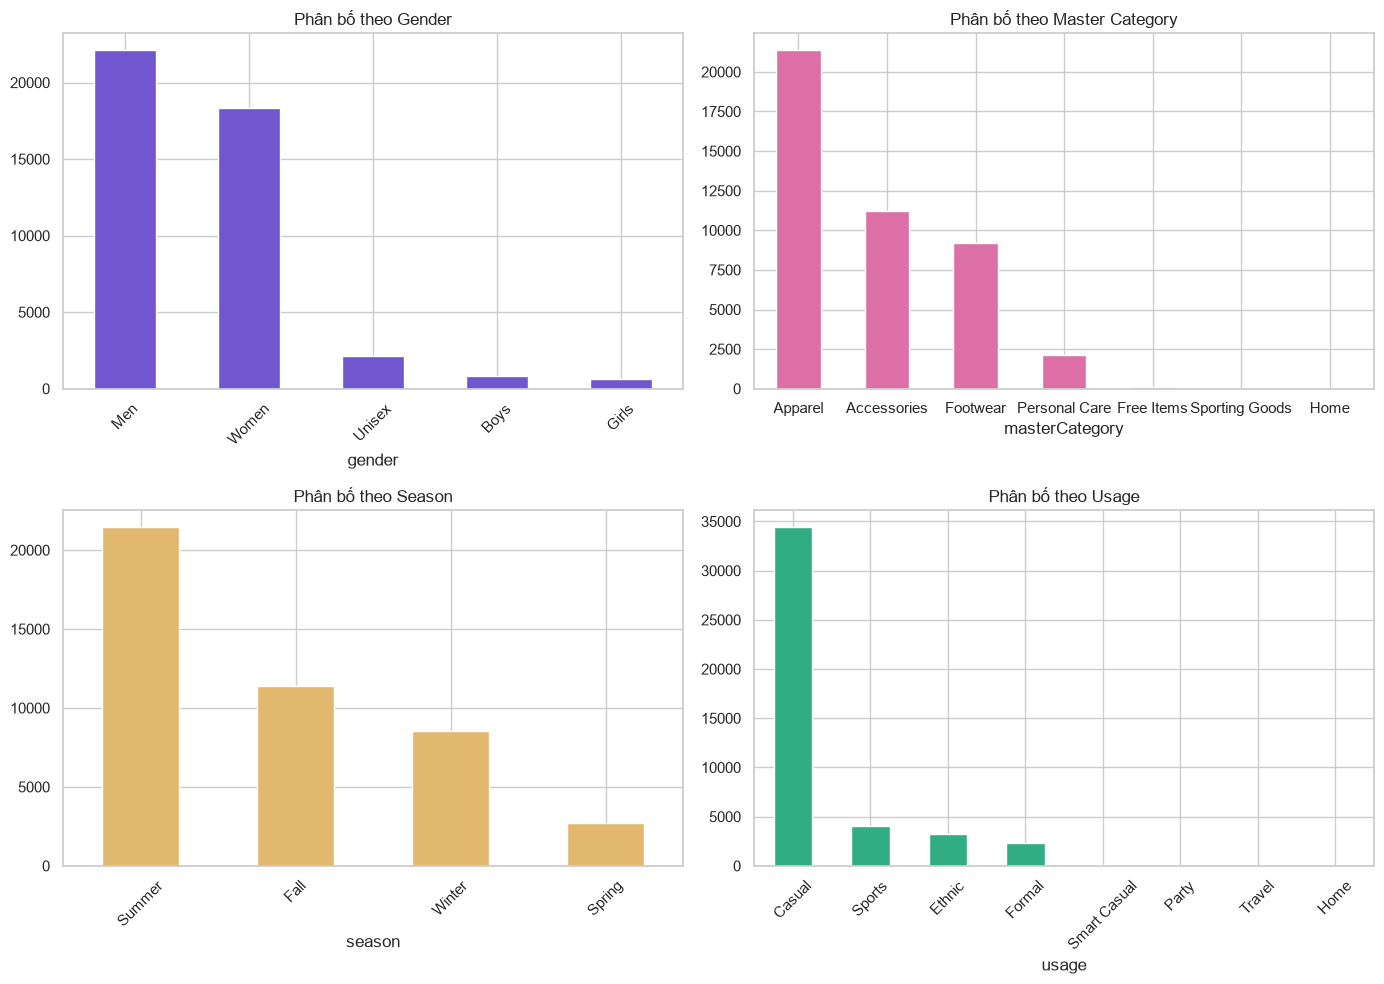

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['gender'].value_counts().plot(kind='bar', ax=axes[0,0], color="#7056cf")
axes[0,0].set_title('Phân bố theo Gender')
axes[0,0].tick_params(axis='x', rotation=45)

df['masterCategory'].value_counts().plot(kind='bar', ax=axes[0,1], color="#dc6fa6")
axes[0,1].set_title('Phân bố theo Master Category')
axes[0,1].tick_params(axis='x', rotation=0)

df['season'].value_counts().plot(kind='bar', ax=axes[1,0], color="#e2b86f")
axes[1,0].set_title('Phân bố theo Season')
axes[1,0].tick_params(axis='x', rotation=45)

df['usage'].value_counts().plot(kind='bar', ax=axes[1,1], color="#31ad84")
axes[1,1].set_title('Phân bố theo Usage')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

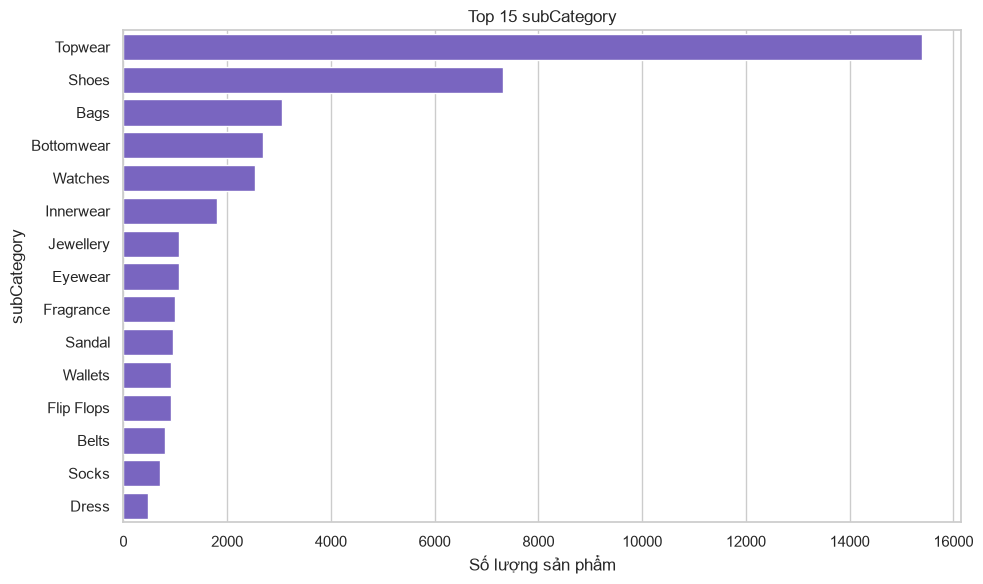

In [74]:
top_sub = df['subCategory'].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_sub.values, y=top_sub.index, color="#7056cf")
plt.title('Top 15 subCategory')
plt.xlabel('Số lượng sản phẩm')
plt.tight_layout()
plt.show()

**Nhận xét**: `Topwear`, `Shoes`, `Bags`, `Bottomwear` và `Watches` chiếm số lượng lớn (hơn 70%).

In [75]:
subcat = df[df.masterCategory == "Accessories"]["subCategory"].value_counts()

result = pd.DataFrame({
    "count": subcat,
    "percentage": (subcat / len(df) * 100).round(2)
})

# Lấy top 10
result[:10]

,count,percentage
subCategory,,
Bags,3053,6.93
Watches,2542,5.77
Jewellery,1079,2.45
Eyewear,1073,2.43
Wallets,925,2.10
Belts,811,1.84
Socks,686,1.56
Headwear,293,0.66
Ties,258,0.59


**Nhận xét**: `Bags`, `Watches`, `Jewellery`, `Eyewear` và `Wallets` là các phụ kiện chiếm độ đa dạng lớn.

In [76]:
vc = df['articleType'].value_counts()
print(f"Số articleType duy nhất: {vc.shape[0]}")
print(f"articleType có <=2 sản phẩm (long tail):")
vc[vc <= 2]

Số articleType duy nhất: 142
articleType có <=2 sản phẩm (long tail):


articleType
Ties and Cufflinks     2
Key chain              2
Toner                  2
Face Serum and Gel     2
Makeup Remover         2
Shoe Laces             1
Hair Accessory         1
Cushion Covers         1
Mens Grooming Kit      1
Body Wash and Scrub    1
Suits                  1
Ipad                   1
Name: count, dtype: int64

## **4. Phân bố các biến numeric**

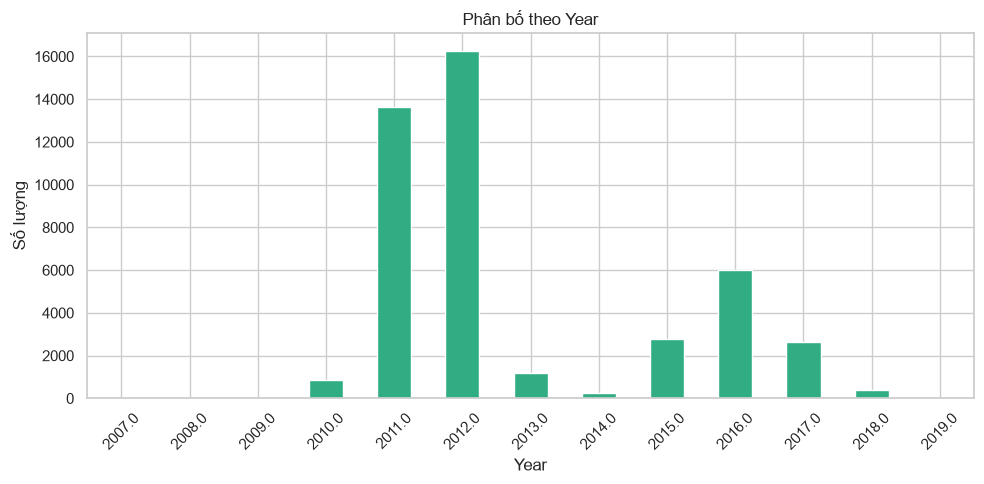

In [77]:
plt.figure(figsize=(10, 5))

df['year'].value_counts().sort_index().plot(
    kind='bar',
    color='#31ad84'
)

plt.title('Phân bố theo Year')
plt.xlabel('Year')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## **5. Kết luận & Lưu file đã tiền xử lý**

In [78]:
# Kiểm tra lại
print("Shape:", df.shape)

print("\nMissing:")
print(df.isna().sum())

print("\nDuplicate:")
print("Full duplicate:", df.duplicated().sum())
print("ID duplicate:", df["id"].duplicated().sum())

Shape: (44077, 10)

Missing:
id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
dtype: int64

Duplicate:
Full duplicate: 0
ID duplicate: 0


**Tổng kết**:

- Dataset có quy mô hơn **44.000 sản phẩm** với 10 thuộc tính chính.
- Dữ liệu có một số giá trị thiếu, tuy nhiên số lượng missing tương đối nhỏ so với tổng số bản ghi. Do đó, có thể loại bỏ các bản ghi thiếu ở những thuộc tính cần thiết mà không ảnh hưởng đáng kể đến quy mô dataset.
- Không phát hiện **duplicate hoàn toàn** hoặc duplicate theo `id`. Tuy nhiên, có một tỷ lệ đáng kể các sản phẩm có cùng `productDisplayName` và `baseColour`. Các bản ghi này không được xem là duplicate vì vẫn có thể khác nhau ở các thuộc tính như `season`, `year` hoặc `id`, do đó được giữ lại.
- Phân bố các biến phân loại cho thấy dataset có sự khác biệt đáng kể về số lượng giữa các nhóm `gender`, `masterCategory`, `subCategory`, `articleType`, `baseColour`, `season` và `usage`. Điều này cần được lưu ý khi sampling để tập dữ liệu cuối cùng không bị lệch quá nhiều về một số nhóm sản phẩm.
- Biến `year` cho thấy dữ liệu được thu thập trong nhiều năm khác nhau, do đó có thể sử dụng thông tin thời gian như một metadata bổ sung cho hệ thống truy xuất.
- Dataset ban đầu có một lỗi định dạng CSV tại **dòng 6044** (record có `id = 44065`), trong đó tên sản phẩm chứa dấu phẩy nhưng không được bao bởi dấu ngoặc kép, khiến dòng này bị nhận thành 11 trường thay vì 10 $\rightarrow$ loại bỏ dòng lỗi này vì tỉ lệ rất nhỏ (chỉ 1 dòng).
- Nhìn chung, sau khi xử lý lỗi định dạng, missing values và kiểm tra tính trùng lặp, dataset có chất lượng phù hợp để tiếp tục **sampling khoảng 5.000–10.000 sản phẩm**, sau đó bổ sung các thuộc tính cần thiết và xây dựng dữ liệu đầu vào cho hệ thống RAG.


In [79]:
# Lưu data đã tiền xử lý
df.to_csv(CLEAN_DATA_PATH, index=False, encoding="utf-8-sig")